In [1]:
#Libraries____________________
import requests
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
from collections import Counter
from goatools.obo_parser import GODag
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from scipy.sparse import csr_matrix #mlb produces a matrix that is too large without compressing
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Masking
from sklearn.utils import resample

In [21]:
df = pd.read_csv("protSQ.tsv", sep="\t") #training data

In [22]:
go_dag = GODag("go.obo")

go.obo: fmt(1.2) rel(2025-06-01) 43,448 Terms


In [ ]:
#if term in go_dag and go_dag[term].namespace == "molecular_function" or term in go_dag and "binding" in go_dag[term].name.lower()

In [23]:
truncate=["ATP","metal ion","rRNA","DNA","RNA","magnesium ion binding","zinc ion binding","GTP","4 iron, 4 sulfur"]
def extrGO(GOterm):
    if pd.isna(GOterm):
        return None
    go_terms = [term.strip() for term in GOterm.split('; ')]
    sel_terms = [
        term for term in go_terms
        if term in go_dag and "binding" in go_dag[term].name.lower()
    ]
    sel_terms = [
        term for term in sel_terms
        if term in go_dag and all(var.lower() not in go_dag[term].name.lower() for var in truncate)
    ]
    return ";".join(sel_terms) if sel_terms else None

In [24]:
df["binding"]=df["Gene Ontology IDs"].apply(extrGO)

In [25]:
df = df[df["binding"].notnull()] 

In [26]:
df.shape

(138559, 4)

In [27]:
#Pre-processing
df["Gene Ontology IDs"]=df["Gene Ontology IDs"].str.split('; ')

In [28]:
print(df.head(3))
print("nrows: ",df.shape[0])
print("ncol: ",df.shape[1])
df.columns

        Entry                                           Sequence  \
2  A0A024B7W1  MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...   
3  A0A024RXP8  MYRKLAVISAFLATARAQSACTLQSETHPPLTWQKCSSGGTCTQQT...   
5  A0A024SH76  MIVGILTTLATLATLAASVPLEERQACSSVWGQCGGQNWSGPTCCA...   

                                   Gene Ontology IDs     binding  
2  [GO:0003724, GO:0003725, GO:0003968, GO:000425...  GO:0008289  
3   [GO:0005576, GO:0016162, GO:0030245, GO:0030248]  GO:0030248  
5   [GO:0005576, GO:0016162, GO:0030245, GO:0030248]  GO:0030248  
nrows:  138559
ncol:  4


Index(['Entry', 'Sequence', 'Gene Ontology IDs', 'binding'], dtype='object')

In [29]:
#Go term histogram_________________________
def go_hist(data_frame):
        go_terms=data_frame.iloc[:,-1] #last column is GO term
        go_terms=go_terms.str.split("; ")
        go_terms=list(chain.from_iterable(go_terms))
        go_terms=[go_dag[term].name for term in go_terms if term in go_dag]
        counts=Counter(go_terms)
        data=pd.DataFrame(counts.items(),columns=["GO","count"])
        data=data.sort_values(by="count",ascending=False)
        plt_data=data.head(25)
        plt.figure(figsize=(12,6))
        plt.bar(plt_data["GO"],plt_data["count"])
        plt.xticks(rotation=90)
        plt.xlabel("GO term")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        return "Histogram created!"

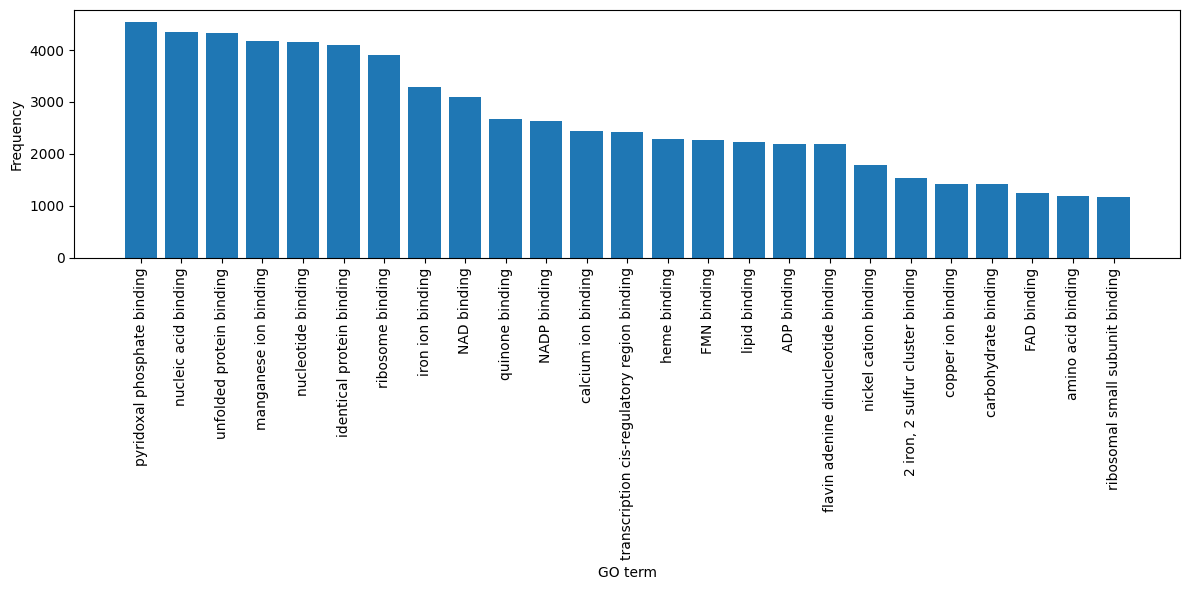

'Histogram created!'

In [30]:
go_hist(df)

In [31]:
#4. Encode y-values________________
mlb = MultiLabelBinarizer(sparse_output=True)

In [32]:
Y_train = mlb.fit_transform(df["Gene Ontology IDs"])
Y_train=Y_train.astype(np.float32)

In [33]:
print(Y_train.dtype)

float32


In [2]:
#5. Encode x-values_____________________
def num_encodeTOK(prot_sq):
    a_acid=["X","A","L","K","W","F","Y","G","D","N","C","T","V","M","R","I","S","P","H","E","Q","U","Z","B","O"]
    num=np.arange(0,25)
    tk_dict=dict(zip(a_acid,num))
    aa_tk=[]
    for aa in prot_sq:
        aa_tk.append(tk_dict[aa])
    return np.array(aa_tk)

In [35]:
sequences=list(df['Sequence'])

In [36]:
#reduce amount of memory needed to store x-values
max_len = 500 #max length to pad to
n_samples = len(sequences)
X_train = np.zeros((n_samples, max_len), dtype=np.uint16)

for i, seq in enumerate(sequences):
    encoded = num_encodeTOK(seq)  
    if len(encoded) > max_len:
        encoded = encoded[:max_len]
    padded = np.pad(encoded, (0, max_len - len(encoded)), constant_values=0)
    X_train[i] = padded
X_train = X_train.astype('int32')

In [37]:
X_train.shape

(138559, 500)

In [38]:
import numpy as np
import tensorflow as tf
from scipy import sparse

num_samples, seq_len = X_train.shape
num_labels = Y_train.shape[1]

# --- Generator yields (x, y_sparse) ---
def data_generator():
    for i in range(num_samples):
        x = X_train[i]
        y_row = Y_train.getrow(i).tocoo()
        indices = np.vstack((y_row.row, y_row.col)).T.astype(np.int64)
        values = y_row.data.astype(np.float32)
        dense_shape = [1, num_labels]

        sparse_tensor = tf.sparse.SparseTensor(indices=indices, values=values, dense_shape=dense_shape)
        sparse_tensor = tf.sparse.reorder(sparse_tensor)  # IMPORTANT: reorder indices here!
        yield x, sparse_tensor

# --- Define dataset ---
output_signature = (
    tf.TensorSpec(shape=(seq_len,), dtype=X_train.dtype),
    tf.SparseTensorSpec(shape=(1, num_labels), dtype=tf.float32)
)

dataset = tf.data.Dataset.from_generator(data_generator, output_signature=output_signature)

# --- Batch and preprocess ---
batch_size = 16
dataset = dataset.batch(batch_size)

def preprocess(x, y_sparse):
    y_sparse = tf.sparse.reorder(y_sparse)  # reorder again just in case after batching
    y_dense = tf.sparse.to_dense(y_sparse, default_value=0.0)
    y_dense = tf.squeeze(y_dense, axis=1)  # (batch_size, 1, num_labels) -> (batch_size, num_labels)
    return x, y_dense

dataset = dataset.map(preprocess)

# --- Build simple model ---
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(seq_len,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_labels, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- Train ---
model.fit(dataset, epochs=5)


C:\Users\teemo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/5
   8660/Unknown 895s 103ms/step - accuracy: 0.0364 - loss: 0.0073

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


8660/8660 ━━━━━━━━━━━━━━━━━━━━ 896s 103ms/step - accuracy: 0.0365 - loss: 0.0073
Epoch 2/5
8660/8660 ━━━━━━━━━━━━━━━━━━━━ 907s 105ms/step - accuracy: 0.0351 - loss: 0.0039
Epoch 3/5
8660/8660 ━━━━━━━━━━━━━━━━━━━━ 941s 109ms/step - accuracy: 0.0351 - loss: 0.0040
Epoch 4/5
8660/8660 ━━━━━━━━━━━━━━━━━━━━ 939s 108ms/step - accuracy: 0.0371 - loss: 0.0039
Epoch 5/5
8660/8660 ━━━━━━━━━━━━━━━━━━━━ 1033s 119ms/step - accuracy: 0.0342 - loss: 0.0039


In [39]:
model.save("g8MLv2.keras")

In [3]:
model = tf.keras.models.load_model("g8MLv2.keras")

In [40]:
# Predict on some data (e.g., first 5 samples)
#1. Pick your protein sequence
#2. Convert it to a token
#3. Flatten and reshape for compatiability
#4. Feed as an X_test
tok = num_encodeTOK("HSWFPQRVPHDGDSVTVETGHLLLLDANTSFLNSLHIKGGKLIFMDPGPIELRAHSILITDGGELHIGSEEKPFQGKARIKIYGSVHSTPFFPYGVKFLAVRNGTLSLHGSVPEVTVTYLQ")

# Convert to float32 if not already
tok = tok.astype(np.float32)

seq_len = 500
X_test = pad_sequences([tok], maxlen=seq_len, padding='post', truncating='post')

# Predict
predictions = model.predict(X_test)

# Output predictions
print(predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
[[1.6625776e-09 5.0012465e-09 2.2763871e-09 ... 3.8062314e-10
  1.3564674e-09 1.2334289e-10]]


In [44]:
print(len(predictions[0]))
for p in predictions[0][150:200]:
    print(p)

23345
1.19619825e-08
2.8642208e-10
4.469453e-09
2.0145546e-10
2.5512445e-10
4.7044274e-10
1.4769689e-11
7.599754e-10
1.819156e-12
5.2135274e-10
1.0004924e-09
4.336882e-10
7.747621e-10
4.2369956e-09
2.2946371e-10
8.415539e-09
1.3994719e-10
1.1590618e-10
2.1891196e-10
9.257774e-10
6.322326e-08
5.514438e-09
2.00281e-09
1.8577577e-08
7.672e-09
1.2335738e-09
8.149125e-09
9.4668454e-11
2.3581053e-09
3.8159684e-09
1.7535345e-06
2.4918123e-10
2.328735e-09
1.4086415e-10
1.2254094e-10
1.0916592e-08
7.609731e-11
2.6554123e-09
1.13534994e-10
9.437784e-09
1.9819718e-10
1.2025367e-09
2.1721666e-10
2.6869298e-11
2.395634e-08
2.1823012e-09
4.3859996e-09
2.02373e-09
7.393896e-07
9.353717e-09


In [45]:
print(min(predictions[0]))

1.8213769e-15


In [46]:
print(max(predictions[0]))

0.87333155


In [47]:
threshold = 1e-8
binary_predictions = (predictions > threshold).astype(int)
print(binary_predictions)

[[0 0 0 ... 0 0 0]]


In [49]:
predicted_go_term = mlb.inverse_transform(binary_predictions)
predicted_go_term = list(predicted_go_term[0])

In [50]:
go_dag = GODag("go.obo")
go_terms_found=[go_dag[term].name for term in predicted_go_term if term in go_dag]
for term in go_terms_found[:20]:
    print(term)

go.obo: fmt(1.2) rel(2025-06-01) 43,448 Terms
acyl binding
acyl carrier activity
autophagosome assembly
urea cycle
citrulline metabolic process
fatty-acyl-CoA binding
G1/S transition of mitotic cell cycle
negative regulation of transcription by RNA polymerase II
SAGA complex
transcription factor TFIIIB complex
incipient cellular bud site
Golgi cis cisterna
SNARE binding
ubiquitin ligase complex
phosphorelay response regulator activity
L-tryptophan biosynthetic process
protein phosphatase type 1 complex
MAPK cascade
nucleotide binding
3'-5'-RNA exonuclease activity


In [51]:
probabilities = model.predict(X_test)
avg_confidence = np.mean(probabilities, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step


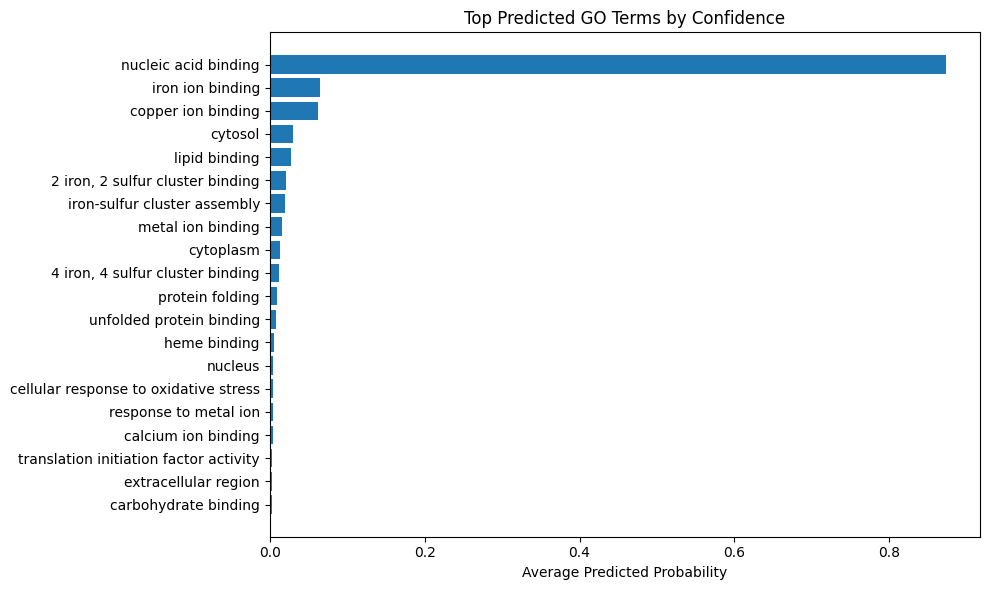

In [52]:
#FOR G8 domain of mouse FPC
top_n = 20
top_indices = np.argsort(avg_confidence)[-top_n:]
top_terms = [mlb.classes_[i] for i in top_indices]
top_terms=[go_dag[term].name for term in top_terms]
top_scores = avg_confidence[top_indices]

# plot
plt.figure(figsize=(10, 6))
plt.barh(top_terms, top_scores)
plt.xlabel('Average Predicted Probability')
plt.title('Top Predicted GO Terms by Confidence')
plt.tight_layout()
plt.show()

In [53]:
#Test for G82 domain
tok2 = num_encodeTOK("KGWGGYNHTIPGPGDDVLILPNKTVLVDTDLPVLRCLYVMGTLEFPVDRSNVLSVACLLIAGGELKVGTLENPLEKDQRLLIFLRASEEVVCDYFEGIHVDPGTIGVYGKLRLHSAYPKKSWVHLGA")

# Convert to float32 if not already
tok2 = tok2.astype(np.float32)

seq_len = 500
X_test2 = pad_sequences([tok2], maxlen=seq_len, padding='post', truncating='post')

# Predict
predictions2 = model.predict(X_test2)

# Output predictions
print(predictions2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
[[6.0140487e-10 1.4075995e-10 1.5874747e-09 ... 2.0763975e-09
  6.5165464e-09 9.4836805e-10]]


In [54]:
threshold = 1e-8
binary_predictions2 = (predictions2 > threshold).astype(int)
print(binary_predictions2)


[[0 0 0 ... 0 0 0]]


In [55]:
predicted_go_term2 = mlb.inverse_transform(binary_predictions2)
predicted_go_term2 = list(predicted_go_term2[0])

In [56]:
go_terms_found2=[go_dag[term].name for term in predicted_go_term2 if term in go_dag]
for term in go_terms_found2[:20]:
    print(term)

maltose catabolic process
mannosyltransferase activity
fatty-acyl-CoA binding
initial mitotic spindle pole body separation
G1/S transition of mitotic cell cycle
negative regulation of transcription by RNA polymerase II
protein phosphatase type 1 complex
nucleotide binding
rRNA (adenine-N6,N6-)-dimethyltransferase activity
tRNA-intron endonuclease complex
vacuolar proton-transporting V-type ATPase, V1 domain
peptidoglycan metabolic process
polysaccharide biosynthetic process
magnesium ion binding
retrograde transport, vesicle recycling within Golgi
mRNA splicing, via spliceosome
autophagy of mitochondrion
maturation of 5.8S rRNA
maturation of LSU-rRNA
box H/ACA snoRNP assembly


In [57]:
probabilities2 = model.predict(X_test2)
avg_confidence2 = np.mean(probabilities2, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


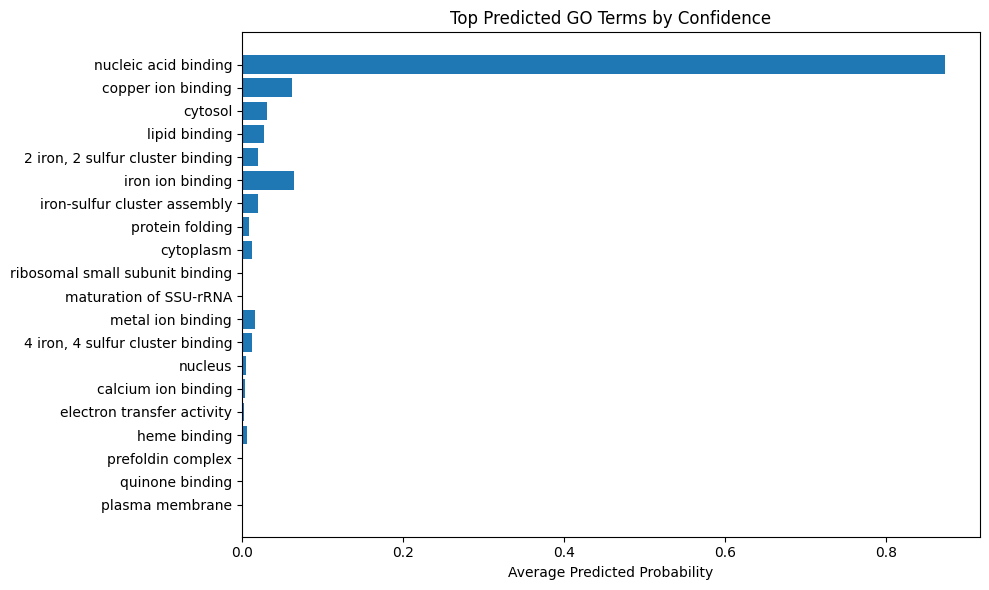

In [58]:
#FOR G82 domain of mouse FPC
top_n = 20
top_indices2 = np.argsort(avg_confidence2)[-top_n:]
top_terms2 = [mlb.classes_[i] for i in top_indices2]
top_terms2=[go_dag[term].name for term in top_terms2]
top_scores2 = avg_confidence[top_indices2]

# plot
plt.figure(figsize=(10, 6))
plt.barh(top_terms2, top_scores2)
plt.xlabel('Average Predicted Probability')
plt.title('Top Predicted GO Terms by Confidence')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
mitochondrion inheritance
vacuole inheritance
single strand break repair
single-stranded DNA endodeoxyribonuclease activity
phosphopyruvate hydratase complex
regulation of DNA recombination
regulation of mitotic recombination
mitotic spindle elongation
maltose metabolic process
maltose catabolic process
alpha-1,2-mannosyltransferase activity
ribosomal large subunit assembly
ribosomal small subunit assembly
mannosyltransferase activity
adenine deaminase activity
acyl binding
acyl carrier activity
very long-chain fatty acid metabolic process
transition metal ion transport
autophagosome assembly
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


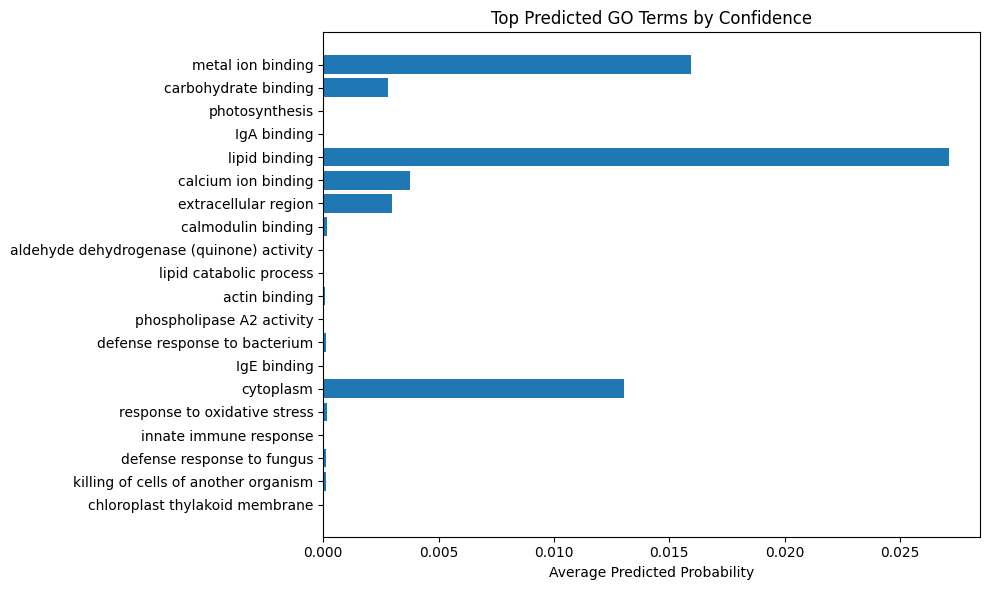

In [59]:
#Try CST
tok_CST = num_encodeTOK("CLVCCWFKKSKTRKIKPE")

# Convert to float32 if not already
tok_CST = tok_CST.astype(np.float32)

seq_len = 500
CST_test = pad_sequences([tok_CST], maxlen=seq_len, padding='post', truncating='post')

# Predict
predictions_CST = model.predict(CST_test)
threshold = 1e-8
binary_predictions_CST = (predictions_CST > threshold).astype(int)

predicted_go_term_CST = mlb.inverse_transform(binary_predictions_CST)
predicted_go_term_CST = list(predicted_go_term_CST[0])

go_terms_found_CST=[go_dag[term].name for term in predicted_go_term_CST if term in go_dag]
for term in go_terms_found_CST[:20]:
    print(term)
    
probabilities_CST = model.predict(CST_test)
avg_confidence_CST = np.mean(probabilities_CST, axis=0)

#FOR G82 domain of mouse FPC
top_n = 20
top_indices_CST = np.argsort(avg_confidence_CST)[-top_n:]
top_terms_CST = [mlb.classes_[i] for i in top_indices_CST]
top_terms_CST=[go_dag[term].name for term in top_terms_CST]
top_scores_CST = avg_confidence[top_indices_CST]

# plot
plt.figure(figsize=(10, 6))
plt.barh(top_terms_CST, top_scores_CST)
plt.xlabel('Average Predicted Probability')
plt.title('Top Predicted GO Terms by Confidence')
plt.tight_layout()
plt.show()